# <h2>Import Libraries<h2>

In [1]:
# Import libraries for data handling and visualization
import pandas as pd        # Provides DataFrame structures for tabular data
import numpy as np         # Offers numerical operations on arrays and matrices
import matplotlib.pyplot as plt  # Used for creating plots and charts
import seaborn as sns      # High-level interface for statistical data visualization

In [2]:
# ===============================
# Import machine learning models
# ===============================
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Tree-based ensemble models
from sklearn.linear_model import LogisticRegression  # Linear classification model
from sklearn.neural_network import MLPClassifier  # Multi-layer perceptron for neural network classification

# ===============================
# Import tools for dataset splitting and validation
# ===============================
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV  # Split datasets and create stratified folds
from sklearn.model_selection import (
    train_test_split, # Split datasets,
    StratifiedKFold, # Create stratified folds
    GridSearchCV   # Perform hyperparameter tuning
)

# ===============================
# Import preprocessing tools
# ===============================
from sklearn.preprocessing import StandardScaler  # Scale numeric features to standard normal distribution

# ===============================
# Import evaluation metrics
# ===============================
from sklearn.metrics import (
    accuracy_score,     # Overall fraction of correct predictions
    precision_score,    # Precision: TP / (TP + FP)
    recall_score,       # Recall: TP / (TP + FN)
    f1_score,           # Harmonic mean of precision and recall
    fbeta_score,        # Weighted F-score, can prioritize recall (beta > 1)
    confusion_matrix,   # Compute confusion matrix
    roc_auc_score,      # Area under the ROC curve
    RocCurveDisplay     # Utility to plot ROC curves directly
)

# ===============================
# Import tools for model inspection
# ===============================
from sklearn.inspection import permutation_importance  # Compute feature importance by shuffling each feature

# ===============================
# Import Pipeline
# ===============================
from sklearn.pipeline import Pipeline # Build preprocessing + model pipelines for streamlined training and scaling

# ===============================
# Additional utilities for custom scoring
# ===============================
from sklearn.metrics import make_scorer, fbeta_score  # Create a custom scorer using F-beta score

# <h2>Load the data<h2>

In [3]:
# ===============================
# Function to load dataset from a CSV file
# ===============================
def load_data(file_path):
    # Read CSV file using pandas, assuming semicolon separator
    df = pd.read_csv(file_path, sep=';')
    return df

# Load the cardiovascular dataset into a DataFrame
cardio_data = load_data("cardio_train.csv")

# Display the first 10 rows of the dataset to inspect its structure
cardio_data.head(10)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0


# <h2>Data Processing and EDA</h2>

In [4]:
# ===============================
# Drop unnecessary columns
# ===============================
# Remove the "id" column since it is just a unique identifier and not useful for modeling
cardio_data = cardio_data.drop(["id"], axis=1)

# Display the first 10 rows to confirm the "id" column has been removed
cardio_data.head(10)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,19834,1,164,68.0,110,60,1,1,0,0,0,0


In [5]:
# ===============================
# Inspect dataset structure
# ===============================
# Use .info() to display:
# - Number of rows and columns
# - Column names
# - Data types of each column
# - Number of non-null values per column
# This helps identify missing values or incorrect data types before preprocessing
print(cardio_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB
None


In [6]:
# ===============================
# Summary statistics of numeric columns
# ===============================
# Use .describe() to get:
# - Count, mean, standard deviation
# - Minimum and maximum values
# - 25th, 50th (median), and 75th percentiles
# This helps understand distributions, spot outliers, and get a sense of feature ranges
cardio_data.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


After loading the dataset and examining summary statistics for all numeric features such as age, height, weight, ap_hi (systolic blood pressure), and ap_lo (diastolic blood pressure).

It was observed that some values were physiologically implausible, for example:

*   Negative or extremely high blood pressure readings (ap_hi up to 16020, ap_lo up to 11000).
*   Unrealistic anthropometric measurements (height of 250 cm, weight of 200 kg, or weight of 10 kg).

To ensure model reliability and reduce noise, these outliers are to be removed from the dataset. This step helps prevent models from learning patterns based on erroneous data, improving overall predictive performance and generalizability.

In [7]:
# Remove physiologically impossible blood pressure values
cardio_data = cardio_data[
    (cardio_data['ap_hi'] > 0) &
    (cardio_data['ap_hi'] < 250) &
    (cardio_data['ap_lo'] > 0) &
    (cardio_data['ap_lo'] < 200) &
    (cardio_data['ap_hi'] > cardio_data['ap_lo'])
]

# Remove unrealistic height and weight measurements
cardio_data = cardio_data[
    (cardio_data['height'] > 120) &
    (cardio_data['height'] < 220) &
    (cardio_data['weight'] > 30) &
    (cardio_data['weight'] < 200)
]

# Convert age from days to years and round to one decimal place
cardio_data['age'] = (cardio_data['age'] / 365).round(1)

In [8]:
# Check to see how many rows were lost
cardio_data.shape

(68615, 12)

In [9]:
# Rerun .describe() to see if there are yet more outliers remaining
cardio_data.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,68615.000000,68615.000000,68615.000000,68615.000000,68615.000000,68615.000000,68615.000000,68615.000000,68615.00000,68615.000000,68615.000000,68615.000000
mean,53.328549,1.348568,164.434351,74.109625,126.673993,81.275392,1.364789,1.225752,0.08794,0.053356,0.803454,0.494746
std,6.761063,0.476520,7.853235,14.280166,16.708488,9.567612,0.678994,0.571588,0.28321,0.224743,0.397389,0.499976
min,29.600000,1.000000,122.000000,31.000000,16.000000,1.000000,1.000000,1.000000,0.00000,0.000000,0.000000,0.000000
25%,48.400000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.00000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.00000,0.000000,1.000000,0.000000
75%,58.400000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.00000,0.000000,1.000000,1.000000
max,65.000000,2.000000,207.000000,183.000000,240.000000,182.000000,3.000000,3.000000,1.00000,1.000000,1.000000,1.000000


In [10]:
# Create a copy of the cleaned dataset for BMI calculation
cardio_data_bmi = cardio_data.copy()

# Create a Body Mass Index (BMI) column as weight (kg) divided by height squared (m^2)
cardio_data_bmi['bmi'] = cardio_data_bmi['weight'] / (cardio_data_bmi['height'] / 100) ** 2

BMI values were retained without additional filtering after prior removal of implausible height and weight values, allowing extreme but valid physiological cases to contribute to model learning

After removing unrealistic height and unrealistic weight, any remaining high BMI values are likely real signals, not noise.

High BMI = Strong Risk Signal



In [11]:
# Rerun .describe() to see if there are yet more outliers remaining
cardio_data_bmi.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
count,68615.000000,68615.000000,68615.000000,68615.000000,68615.000000,68615.000000,68615.000000,68615.000000,68615.00000,68615.000000,68615.000000,68615.000000,68615.000000
mean,53.328549,1.348568,164.434351,74.109625,126.673993,81.275392,1.364789,1.225752,0.08794,0.053356,0.803454,0.494746,27.443873
std,6.761063,0.476520,7.853235,14.280166,16.708488,9.567612,0.678994,0.571588,0.28321,0.224743,0.397389,0.499976,5.221003
min,29.600000,1.000000,122.000000,31.000000,16.000000,1.000000,1.000000,1.000000,0.00000,0.000000,0.000000,0.000000,10.726644
25%,48.400000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.00000,0.000000,1.000000,0.000000,23.875115
50%,54.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.00000,0.000000,1.000000,0.000000,26.346494
75%,58.400000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.00000,0.000000,1.000000,1.000000,30.116213
max,65.000000,2.000000,207.000000,183.000000,240.000000,182.000000,3.000000,3.000000,1.00000,1.000000,1.000000,1.000000,108.169847


# <h2>Data Visualisation</h2>

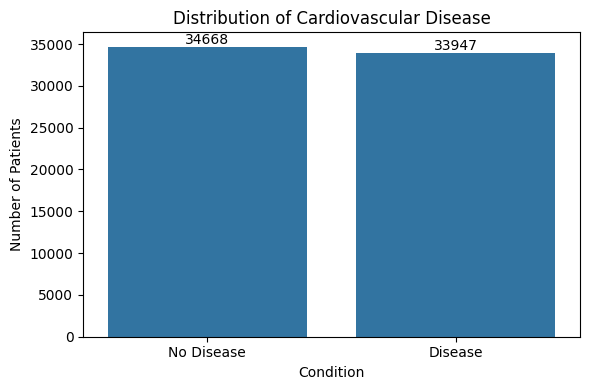

In [12]:
# This plot shows the distribution of the target variable (cardio).
# It visually compares the number of patients with and without cardiovascular disease.
# Annotated counts make it easier to interpret class balance in the dataset.

# Create a figure of size 6x4 inches
plt.figure(figsize=(6,4))

# Plot a countplot of the 'cardio' target variable
ax = sns.countplot(x='cardio', data=cardio_data_bmi)

# Set x-axis labels for better readability
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease', 'Disease'])

# Annotate each bar with its count value
for p in ax.patches:
    height = int(p.get_height())  # Get the height of the bar
    ax.annotate(f'{height}',      # Display count as text
                (p.get_x() + p.get_width() / 2., height),  # Position in the center top of the bar
                ha='center', va='bottom')

# Set title and axis labels
plt.title("Distribution of Cardiovascular Disease")
plt.xlabel("Condition")
plt.ylabel("Number of Patients")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

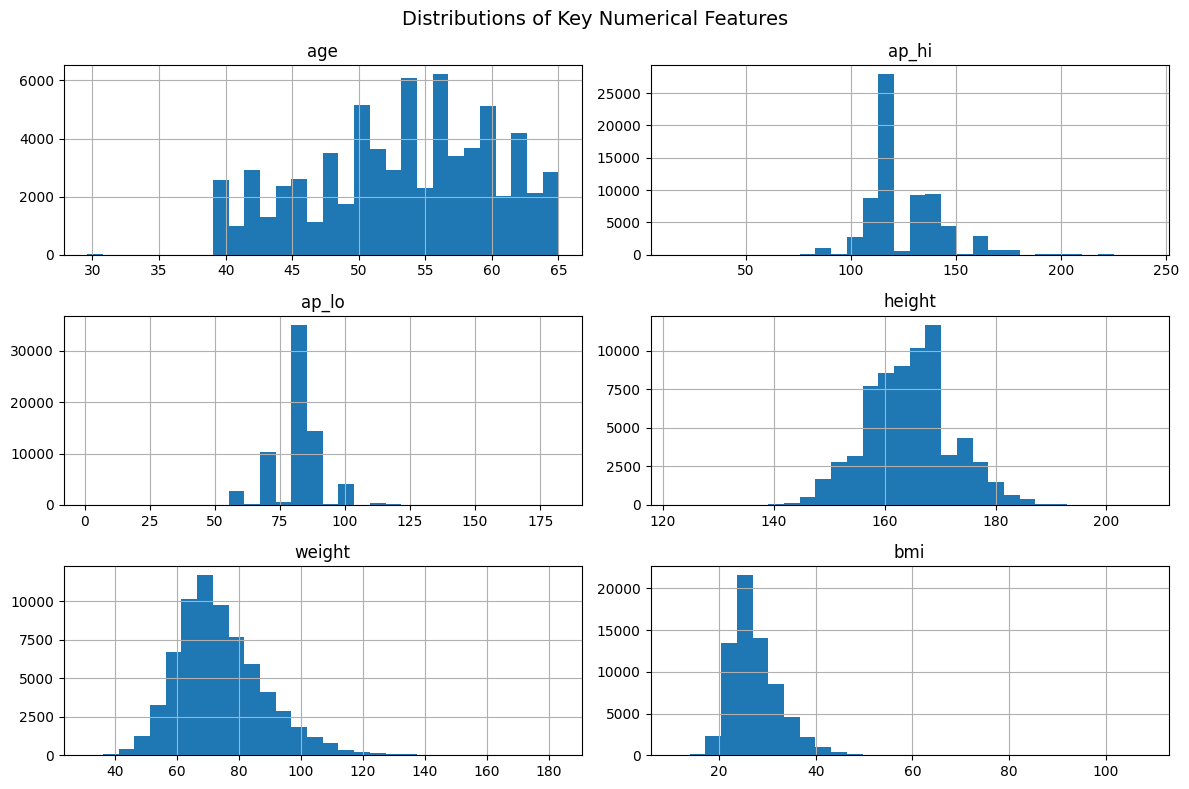

In [13]:
# Histograms show the distributions of key numerical features, including age, blood pressure, height, weight, and BMI.
# This helps in identifying skewed distributions, potential outliers, and overall patterns before model training.

# Select the key numerical features to visualize
features = ['age', 'ap_hi', 'ap_lo', 'height', 'weight', 'bmi']

# Plot histograms for each selected feature in a 12x8 inch figure
cardio_data_bmi[features].hist(figsize=(12,8), bins=30)

# Add a main title for the full figure
plt.suptitle("Distributions of Key Numerical Features", fontsize=14)

# Adjust spacing so titles and plots do not overlap
plt.tight_layout()
plt.show()

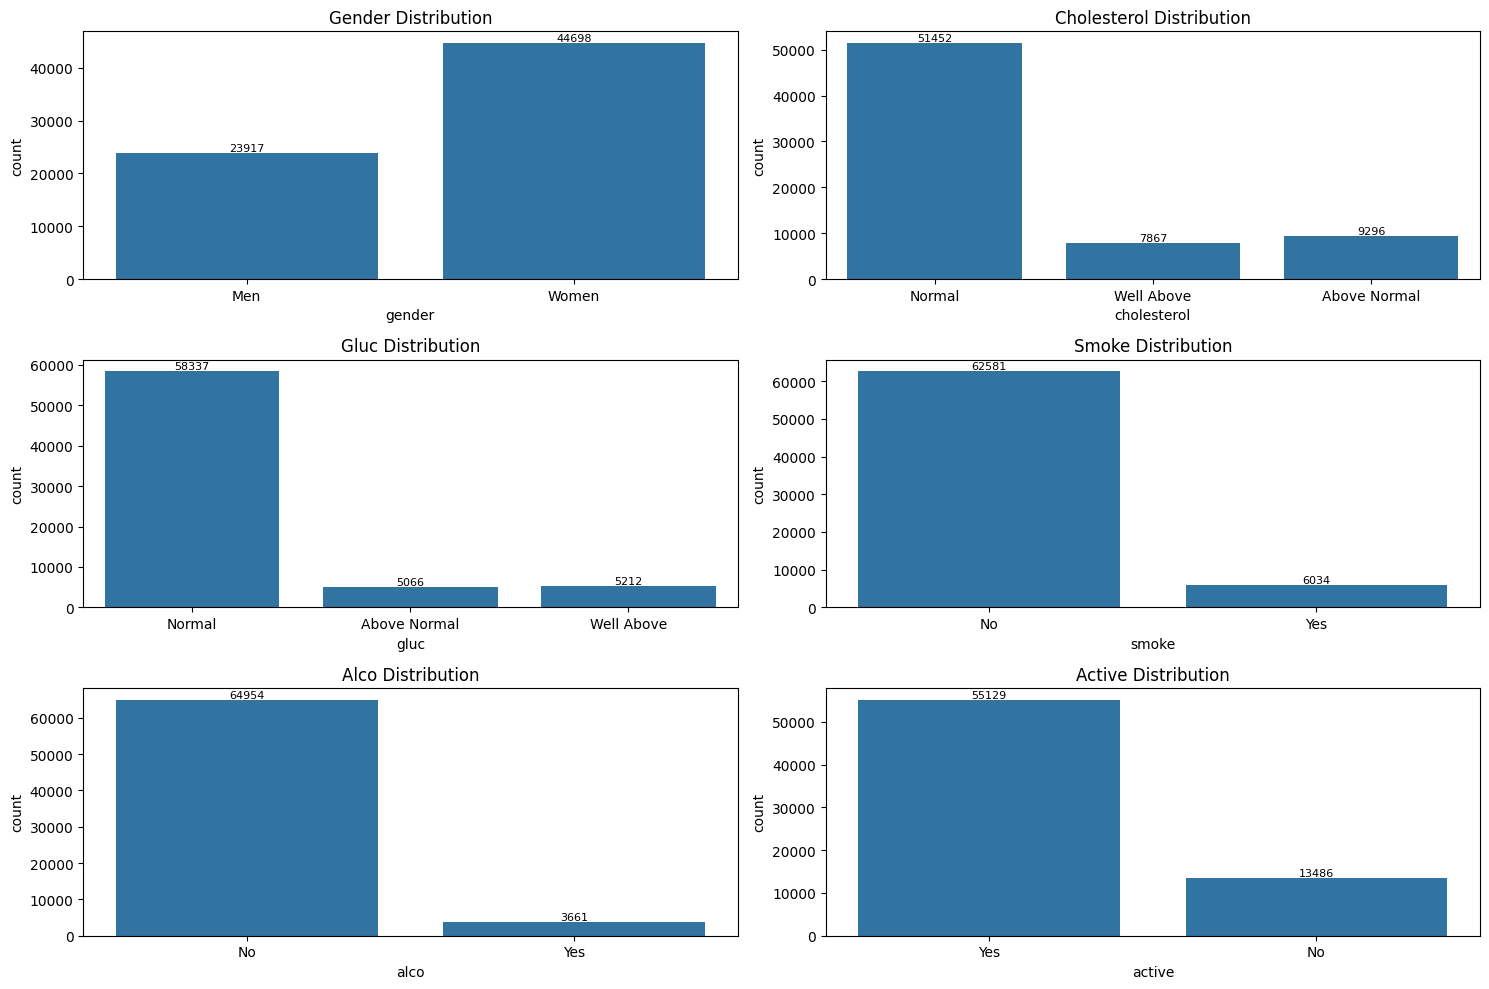

In [14]:
# Countplots visualize the distribution of categorical features such as gender, cholesterol,
# glucose levels, smoking, alcohol consumption, and physical activity.
# Mapping numeric codes to readable labels improves interpretability.
# Annotated counts provide clear insight into class imbalances or dominant categories.


# Make a copy for safe visualization and mapping of categorical codes
viz_data = cardio_data_bmi.copy()

# Map numeric codes to readable labels for categorical variables
viz_data['gender'] = viz_data['gender'].map({1: 'Women', 2: 'Men'})
viz_data['cholesterol'] = viz_data['cholesterol'].map({
    1: 'Normal', 2: 'Above Normal', 3: 'Well Above'
})
viz_data['gluc'] = viz_data['gluc'].map({
    1: 'Normal', 2: 'Above Normal', 3: 'Well Above'
})
viz_data['smoke'] = viz_data['smoke'].map({0: 'No', 1: 'Yes'})
viz_data['alco'] = viz_data['alco'].map({0: 'No', 1: 'Yes'})
viz_data['active'] = viz_data['active'].map({0: 'No', 1: 'Yes'})

# List of categorical features to visualize
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

# Create a 15x10 inch figure for subplots
plt.figure(figsize=(15,10))

# Plot countplots for each categorical feature
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(3, 2, i)  # Arrange plots in a 3x2 grid
    ax = sns.countplot(x=feature, data=viz_data)

    # Annotate bars with counts for readability
    for p in ax.patches:
        height = int(p.get_height())
        ax.annotate(f'{height}',
                    (p.get_x() + p.get_width()/2., height),
                    ha='center', va='bottom', fontsize=8)

    # Title for each subplot
    plt.title(f"{feature.capitalize()} Distribution")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

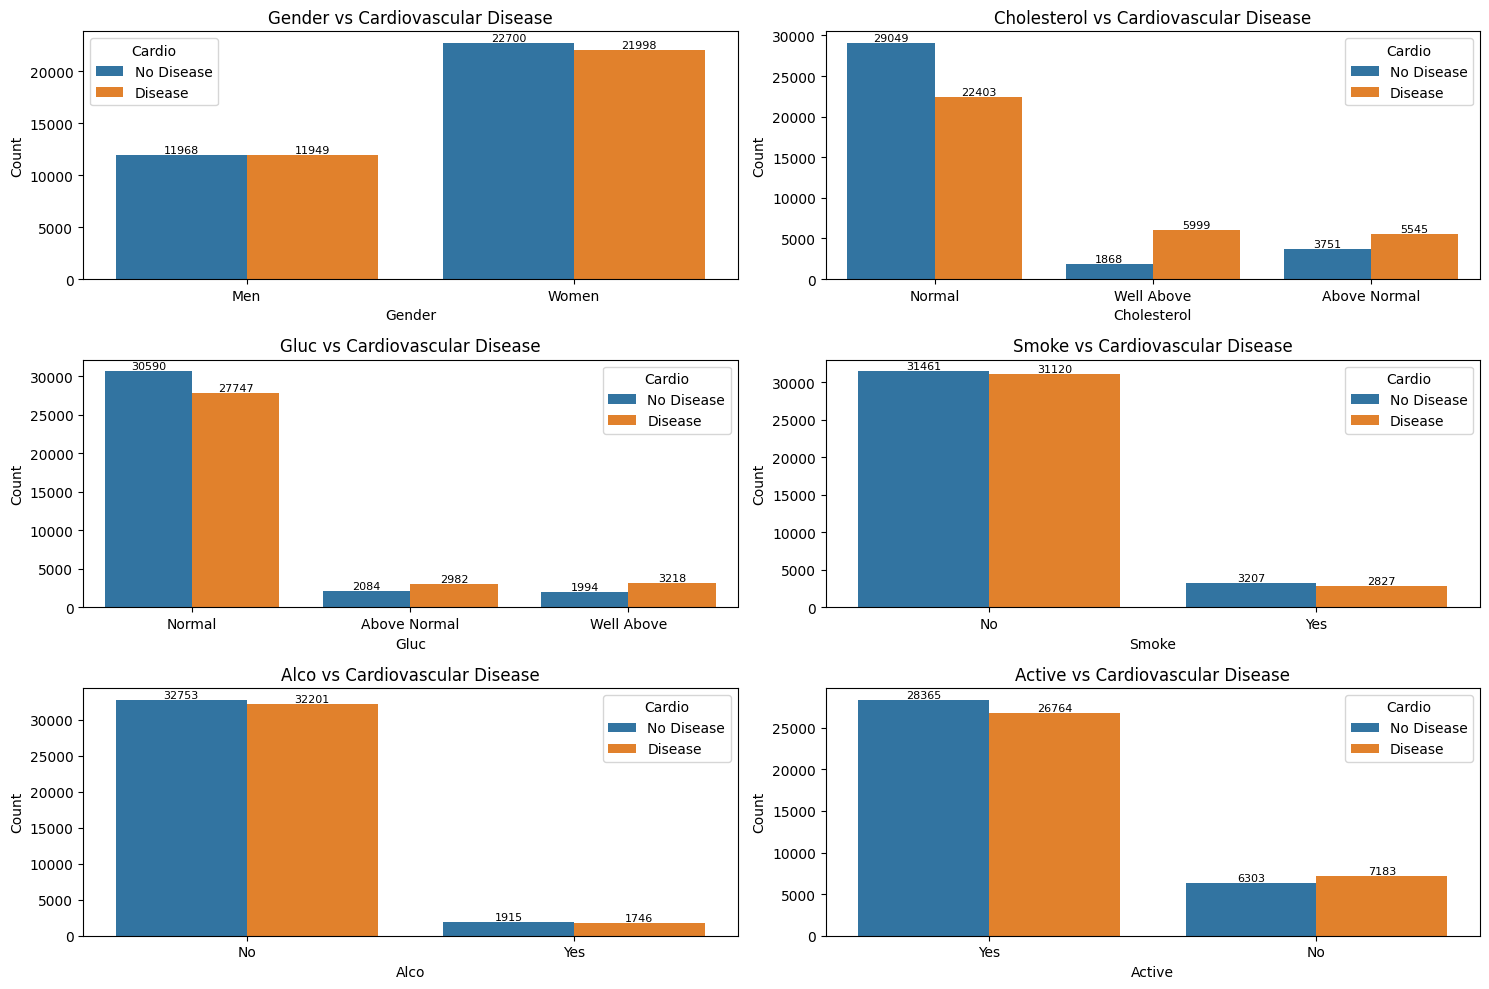

In [15]:
# These visualizations show the relationship between categorical features and cardiovascular disease.
# Using hue='cardio' allows comparison of disease vs no disease within each category.
# Annotated counts help identify imbalances or trends, e.g., more men or smokers with cardiovascular disease.

# List of categorical features for analysis against the target
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

# Create a larger figure for multiple subplots
plt.figure(figsize=(15,10))

# Loop through each categorical feature to plot against cardio outcome
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(3, 2, i)  # Arrange plots in a 3x2 grid

    # Countplot with hue='cardio' to separate by cardiovascular disease
    ax = sns.countplot(x=feature, hue='cardio', data=viz_data)

    # Annotate bars with counts for readability
    for p in ax.patches:
        height = int(p.get_height())
        if height > 0:  # avoid annotating zero-height bars
            ax.annotate(f'{height}',
                        (p.get_x() + p.get_width()/2., height),
                        ha='center', va='bottom', fontsize=8)

    # Titles and axis labels
    plt.title(f"{feature.capitalize()} vs Cardiovascular Disease")
    plt.xlabel(feature.capitalize())
    plt.ylabel("Count")

    # Legend with descriptive labels
    plt.legend(title='Cardio', labels=['No Disease', 'Disease'])

# Adjust layout to prevent overlap between subplots
plt.tight_layout()
plt.show()

In [16]:
# These tables summarize the distribution of cardiovascular disease across categorical features.
# For each category (e.g., gender, cholesterol level), we calculate the total number of individuals
# and the percentage affected by cardiovascular disease.
# This helps identify high-risk groups and understand how categorical features relate to disease prevalence.

# List of categorical features to examine
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

# Loop through each categorical feature to create contingency tables
for feature in categorical_features:
    # Crosstab: counts of No Disease vs Disease for each category
    ct = pd.crosstab(viz_data[feature], viz_data['cardio'])

    # Rename columns for clarity
    ct.columns = ['No Disease', 'Disease']

    # Add total count per category
    ct['Total'] = ct.sum(axis=1)

    # Compute percentage of disease cases within each category
    ct['Disease %'] = (ct['Disease'] / ct['Total'] * 100).round(1)

    # Display the table with a clear header
    print(f"=== {feature.capitalize()} vs Cardiovascular Disease ===")
    display(ct)
    print("\n")

=== Gender vs Cardiovascular Disease ===


,No Disease,Disease,Total,Disease %
gender,,,,
Men,11968,11949,23917,50.0
Women,22700,21998,44698,49.2




=== Cholesterol vs Cardiovascular Disease ===


,No Disease,Disease,Total,Disease %
cholesterol,,,,
Above Normal,3751,5545,9296,59.6
Normal,29049,22403,51452,43.5
Well Above,1868,5999,7867,76.3




=== Gluc vs Cardiovascular Disease ===


...

,No Disease,Disease,Total,Disease %
smoke,,,,
No,31461,31120,62581,49.7
Yes,3207,2827,6034,46.9




=== Alco vs Cardiovascular Disease ===


,No Disease,Disease,Total,Disease %
alco,,,,
No,32753,32201,64954,49.6
Yes,1915,1746,3661,47.7




=== Active vs Cardiovascular Disease ===


,No Disease,Disease,Total,Disease %
active,,,,
No,6303,7183,13486,53.3
Yes,28365,26764,55129,48.5


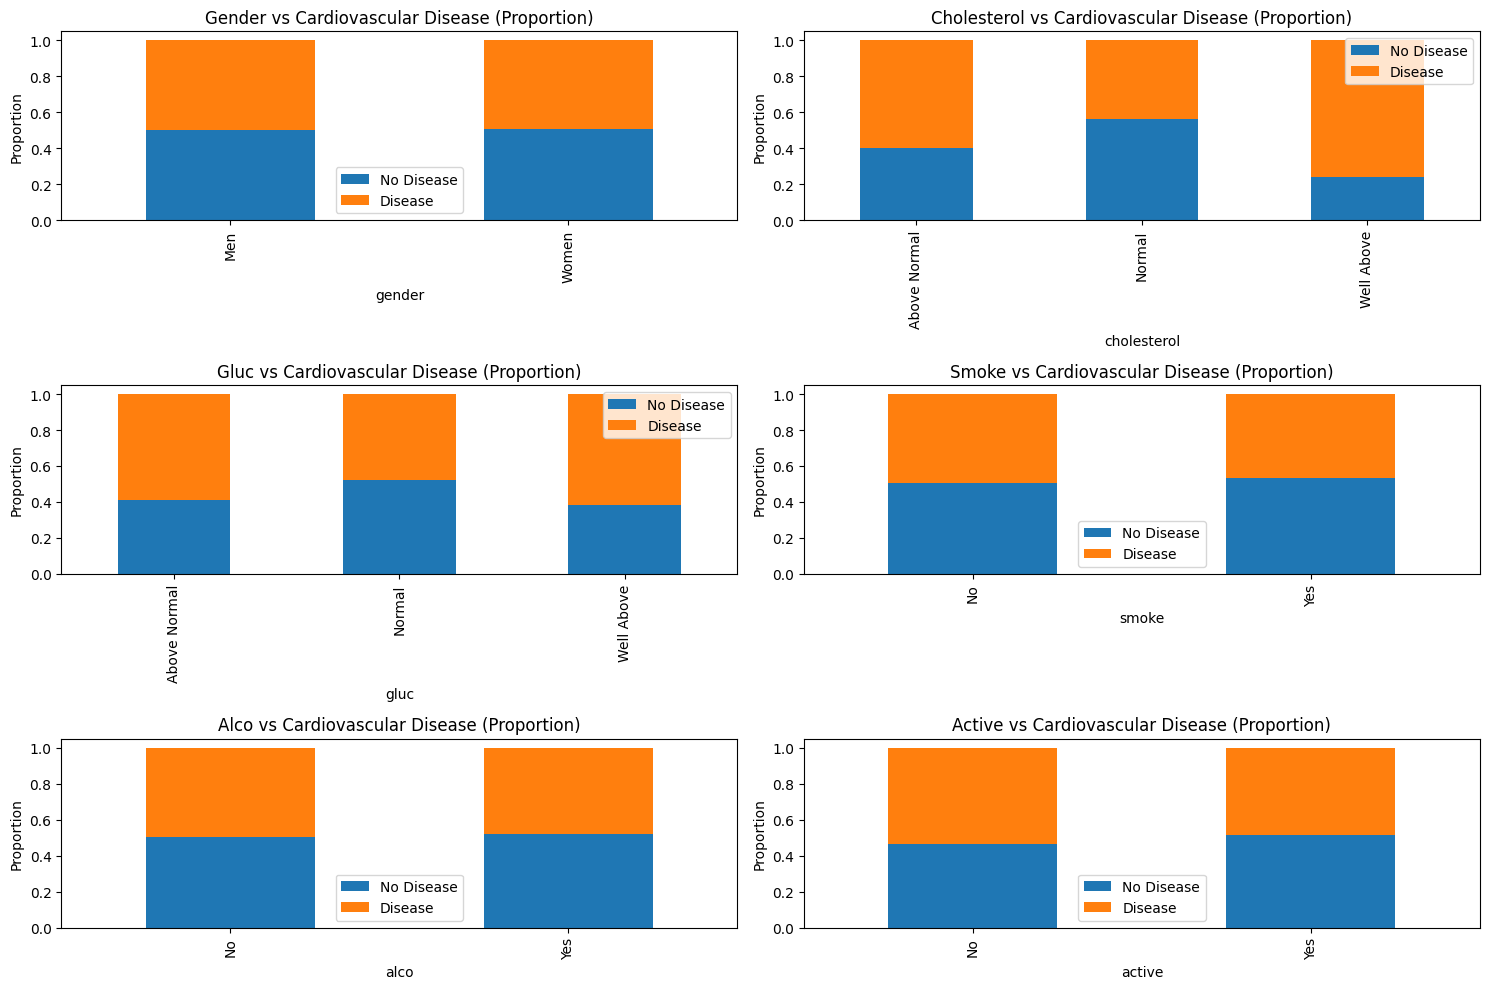

In [17]:
# These stacked bar charts show the proportion of patients with and without cardiovascular disease
# for each category of the selected features.
# Using proportions instead of raw counts allows easier comparison between groups of different sizes,
# highlighting which categories have higher relative disease prevalence.

# Visualize the proportion of disease vs no disease across categorical features
plt.figure(figsize=(15,10))

for i, feature in enumerate(categorical_features, 1):
    plt.subplot(3, 2, i)

    # Compute proportions of each class (disease/no disease) within each category
    prop_df = pd.crosstab(viz_data[feature], viz_data['cardio'], normalize='index')

    # Create a stacked bar chart showing proportions
    prop_df.plot(kind='bar', stacked=True, ax=plt.gca())

    # Add informative titles and labels
    plt.title(f"{feature.capitalize()} vs Cardiovascular Disease (Proportion)")
    plt.ylabel("Proportion")
    plt.legend(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

Encoding

*   Keeping cholesterol and gluc as ordinal (1 → normal, 2 → above normal, 3 → well above)

*   Binary features (smoke, alco, active) already 0/1, so is left untouched

*   Gender is now separated to male and female columns to make feature importance interpretation more straightforward (easier to see which gender is more associated with cardiovascular risk).


In [18]:
# Create a copy to prevent changes to the original dataframe
cardio_data_bmi_encoded = cardio_data_bmi.copy()

# One-hot encode the 'gender' column into separate binary columns
cardio_data_bmi_encoded = pd.get_dummies(cardio_data_bmi_encoded, columns=['gender'], prefix='gender')

# Ordinal encoding: convert cholesterol and glucose levels to numeric categories (1=Normal, 2=Above Normal, 3=Well Above)
ordinal_features = ['cholesterol', 'gluc']
for col in ordinal_features:
    cardio_data_bmi_encoded[col] = cardio_data_bmi_encoded[col].astype('category').cat.codes + 1

# Rename gender columns for clarity
cardio_data_bmi_encoded.rename(columns={'gender_1': 'female', 'gender_2': 'male'}, inplace=True)

# Show the first few rows to verify encoding
cardio_data_bmi_encoded.head()

,age,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,female,male
0,50.4,168,62.0,110,80,1,1,0,0,1,0,21.967120,False,True
1,55.4,156,85.0,140,90,3,1,0,0,1,1,34.927679,True,False
2,51.7,165,64.0,130,70,3,1,0,0,0,1,23.507805,True,False
3,48.3,169,82.0,150,100,1,1,0,0,1,1,28.710479,False,True
4,47.9,156,56.0,100,60,1,1,0,0,0,0,23.011177,True,False


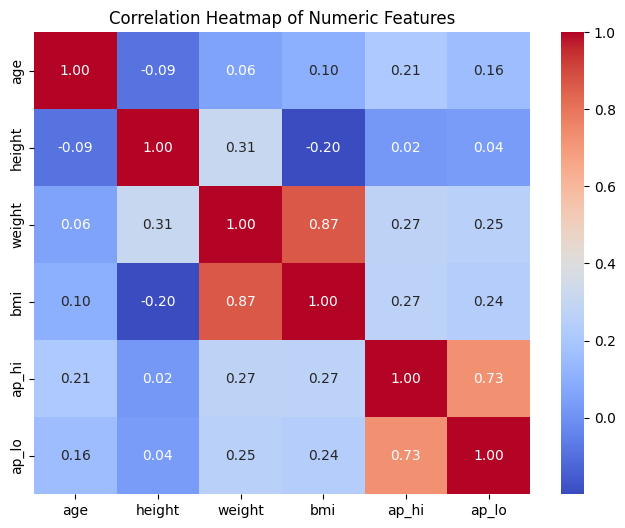

In [19]:
# Select numeric features for correlation analysis
numeric_cols = ['age', 'height', 'weight', 'bmi', 'ap_hi', 'ap_lo']

# Compute pairwise Pearson correlation coefficients between numeric features
corr_matrix = cardio_data_bmi[numeric_cols].corr()

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")  # annotations show correlation values
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

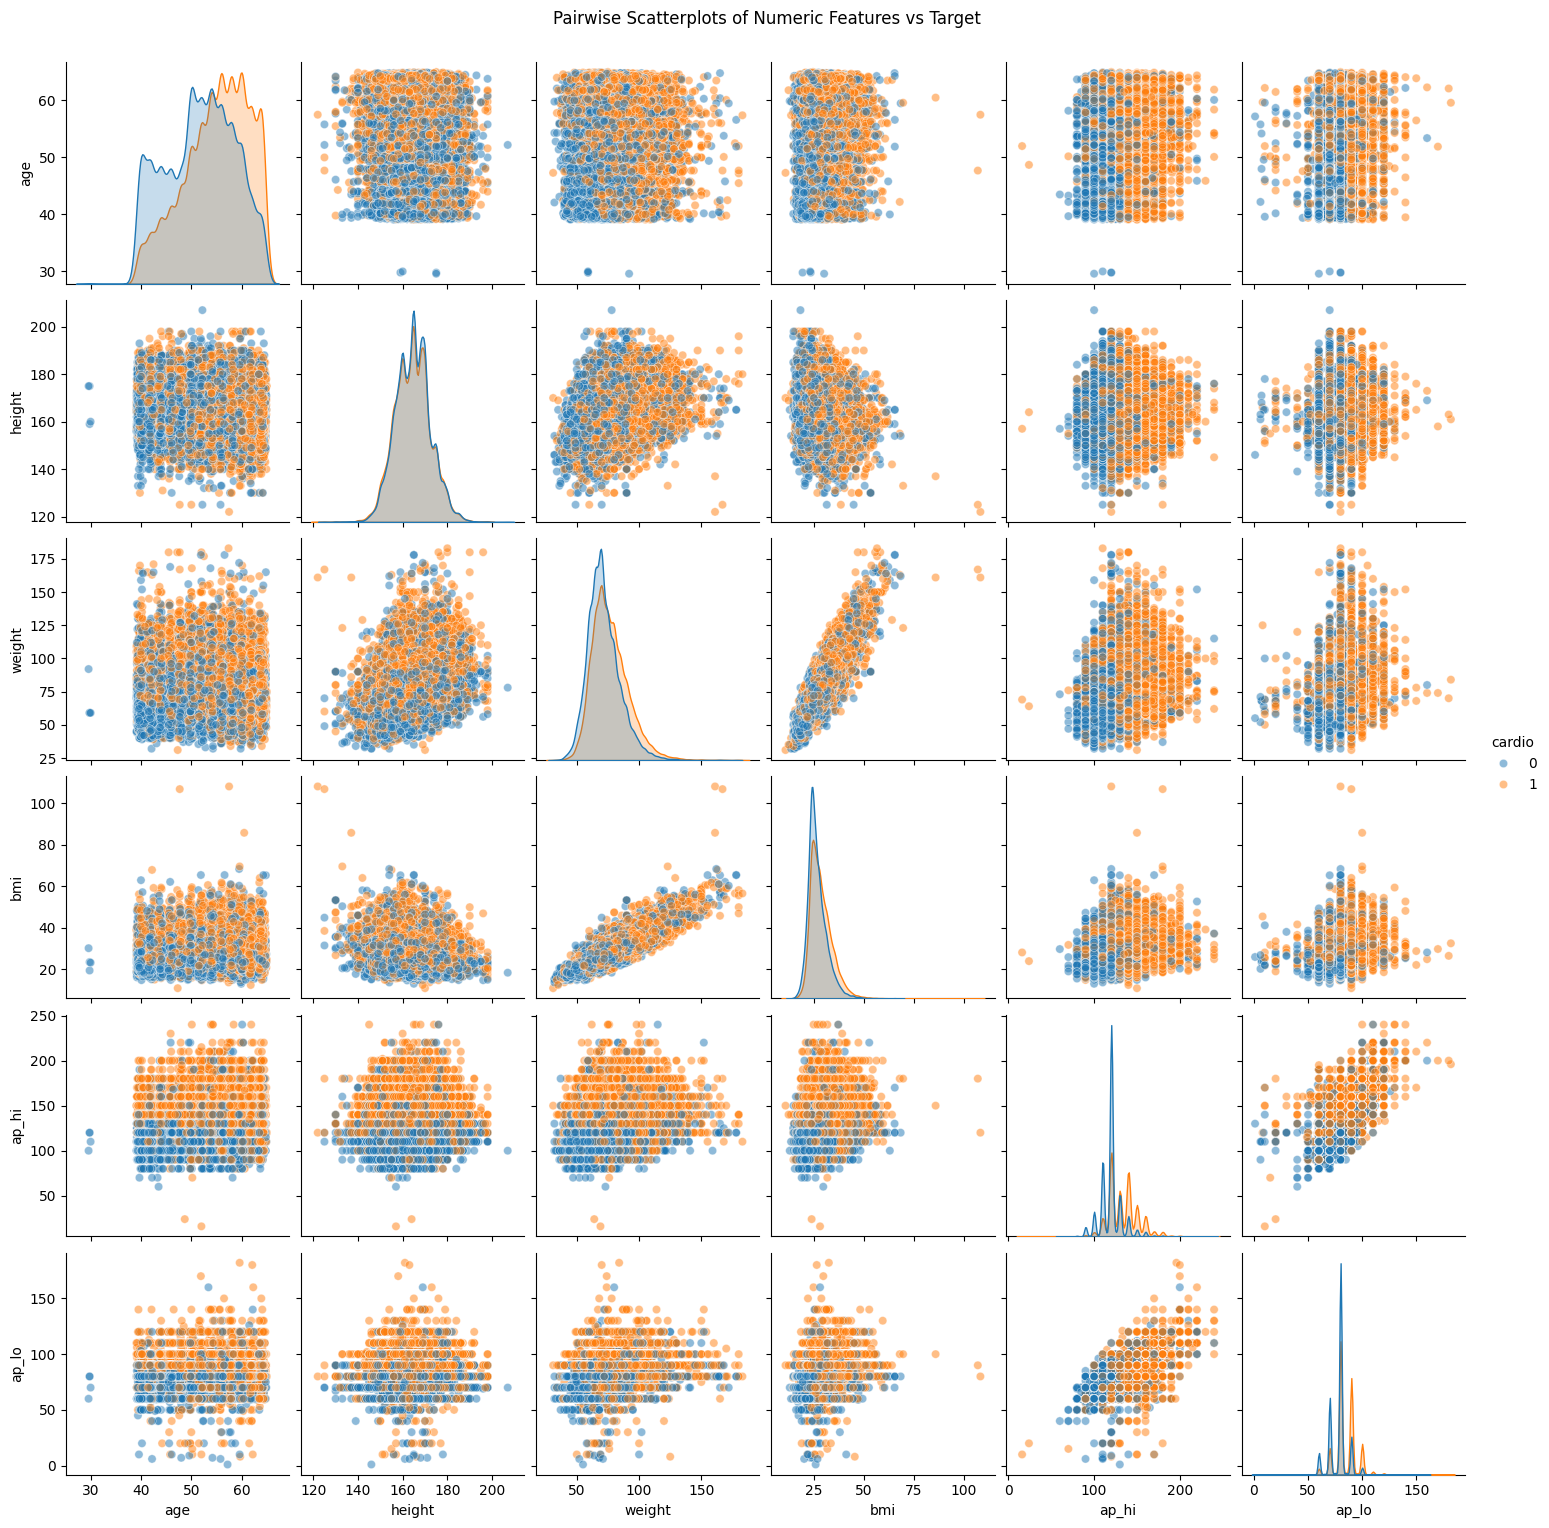

In [20]:
# Pairwise scatterplots for numeric features colored by cardiovascular outcome
# diag_kind='kde' uses density plots on the diagonal for each feature
# plot_kws={'alpha':0.5} makes points semi-transparent to reduce overplotting
sns.pairplot(cardio_data_bmi[numeric_cols + ['cardio']],
             hue='cardio', diag_kind='kde', plot_kws={'alpha':0.5})

# Add a main title for the figure
plt.suptitle("Pairwise Scatterplots of Numeric Features vs Target", y=1.02)
plt.show()

# <h2>Feature Importance</h2>

In [21]:
# Split features and target
X_full = cardio_data_bmi.drop(columns='cardio')  # Features
y_full = cardio_data_bmi['cardio']              # Target

# Train a Random Forest on the full dataset to assess feature importance
rf_full = RandomForestClassifier(n_estimators=200, random_state=42)
rf_full.fit(X_full, y_full)

# Extract feature importances from the trained model
feature_importances = pd.Series(rf_full.feature_importances_, index=X_full.columns)

# Sort feature importances in descending order
feature_importances.sort_values(ascending=False, inplace=True)

# Display feature importances
feature_importances

age            0.235426
bmi            0.169092
ap_hi          0.168183
weight         0.121791
height         0.116820
ap_lo          0.085956
cholesterol    0.038555
gender         0.017148
gluc           0.016883
active         0.014191
smoke          0.008734
alco           0.007220
dtype: float64

In [22]:
# Define feature importance thresholds to select the most relevant features
thresholds = [0.01, 0.03]
datasets = {}

for t in thresholds:
    # Select features whose importance exceeds the threshold
    selected_features = feature_importances[feature_importances > t].index.tolist()

    # Store the subset of features for this threshold
    datasets[f"Importance > {t}"] = X_full[selected_features]

    # Print the selected features for reference
    print(f"Features (threshold {t}): {selected_features}")

Features (threshold 0.01): ['age', 'bmi', 'ap_hi', 'weight', 'height', 'ap_lo', 'cholesterol', 'gender', 'gluc', 'active']
Features (threshold 0.03): ['age', 'bmi', 'ap_hi', 'weight', 'height', 'ap_lo', 'cholesterol']


# <h2>Implementing The Model</h2>

Model Definitions

In [23]:
# Define a dictionary of candidate models with their configurations
# Each model includes a flag indicating whether numeric features should be scaled
models = {
    "Random Forest": {
        "model": RandomForestClassifier(n_estimators=200, random_state=42),
        "scaled": False  # Tree-based models do not require feature scaling
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(n_estimators=200, random_state=42),
        "scaled": False  # Tree-based model
    },
    "MLP": {
        "model": MLPClassifier(
            hidden_layer_sizes=(50,),
            max_iter=200,
            early_stopping=True,
            random_state=42
        ),
        "scaled": True  # Neural networks benefit from feature scaling
    },
    "Logistic Regression": {
        "model": LogisticRegression(
            max_iter=500,
            solver='liblinear',
            random_state=42
        ),
        "scaled": True  # Linear model benefits from scaling
    }
}

In [24]:
# List of numeric columns in the dataset
# These features will be used for scaling and model input
numeric_cols = ['age', 'height', 'weight', 'bmi', 'ap_hi', 'ap_lo']

Evaluation Function

In [25]:
# This function evaluates a trained classification model.
# It computes key metrics (Accuracy, Precision, Recall, F1, F2, ROC-AUC),
# plots a confusion matrix, and optionally returns the predicted probabilities for further analysis like ROC curves.
# F2 is included because it prioritizes recall, which is critical for medical diagnosis tasks where false negatives are costly.

def evaluate_model(model, X_eval, y_eval, model_name="Model", return_proba=False):
    # Predict class labels
    y_pred = model.predict(X_eval)

    # Predict probabilities if available (needed for ROC-AUC)
    y_proba = model.predict_proba(X_eval)[:,1] if hasattr(model, "predict_proba") else None

    # Compute standard classification metrics
    acc = accuracy_score(y_eval, y_pred)             # Overall accuracy
    prec = precision_score(y_eval, y_pred)          # Precision: TP / (TP + FP)
    rec = recall_score(y_eval, y_pred)              # Recall: TP / (TP + FN)
    f1 = f1_score(y_eval, y_pred)                   # Harmonic mean of precision & recall
    f2 = fbeta_score(y_eval, y_pred, beta=2)        # Weighted F-score prioritizing recall
    roc_auc = roc_auc_score(y_eval, y_proba) if y_proba is not None else np.nan

    # Plot confusion matrix
    cm = confusion_matrix(y_eval, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease','Disease'],
                yticklabels=['No Disease','Disease'])
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Collect metrics in a dictionary
    metrics = {"Model": model_name, "Accuracy": acc, "Precision": prec,
               "Recall": rec, "F1": f1, "F2": f2, "ROC-AUC": roc_auc}

    # Optionally return predicted probabilities for further analysis (e.g., ROC curves)
    if return_proba:
        return metrics, y_proba
    else:
        return metrics

Pipeline for Each Dataset


=== Running models for Importance > 0.01 ===
Training Random Forest...


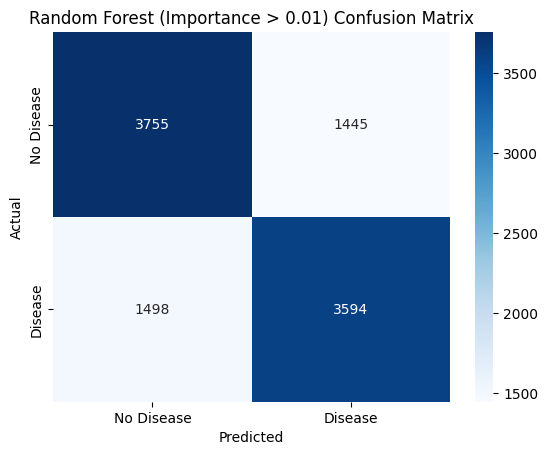

Training Gradient Boosting...


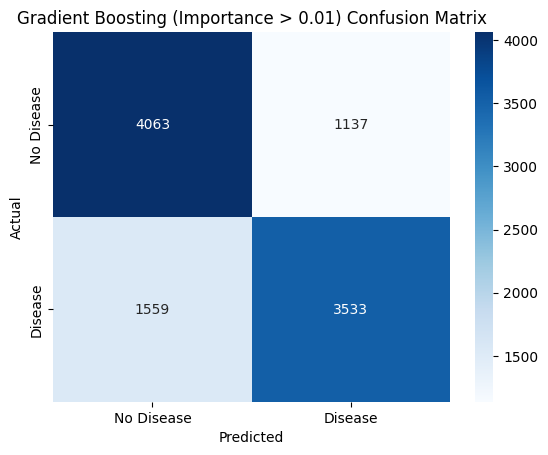

Training MLP...


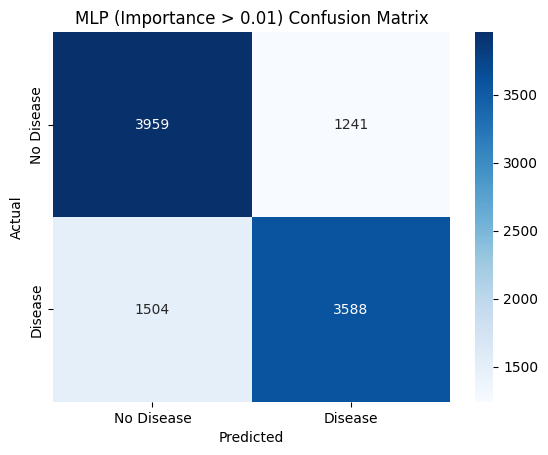

Training Logistic Regression...


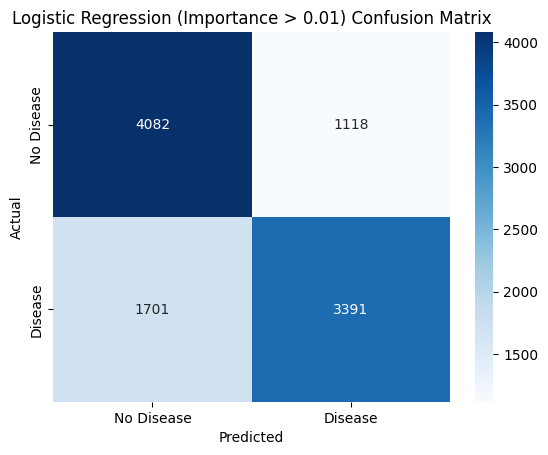


=== Running models for Importance > 0.03 ===
Training Random Forest...


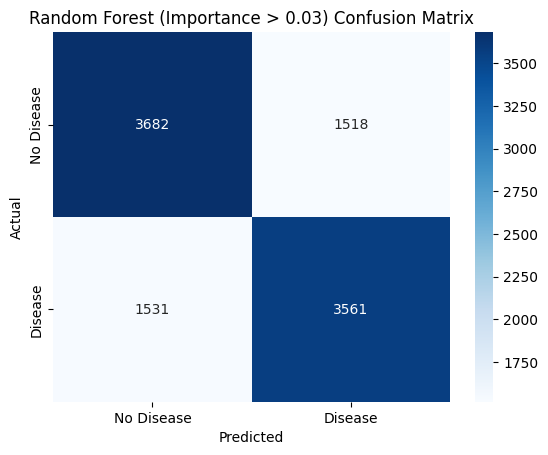

Training Gradient Boosting...


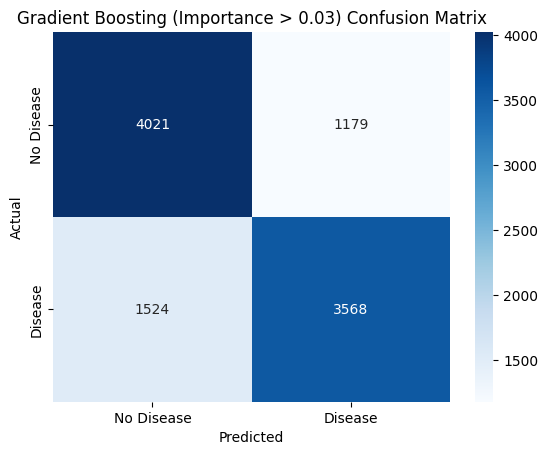

Training MLP...


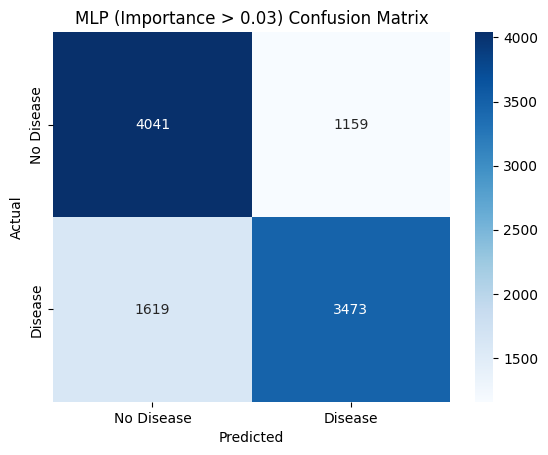

Training Logistic Regression...


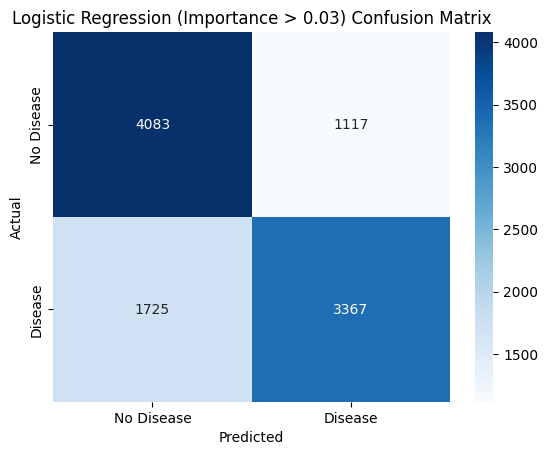

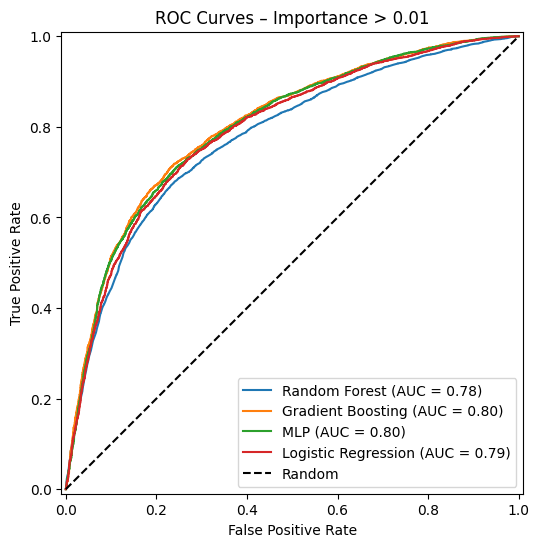

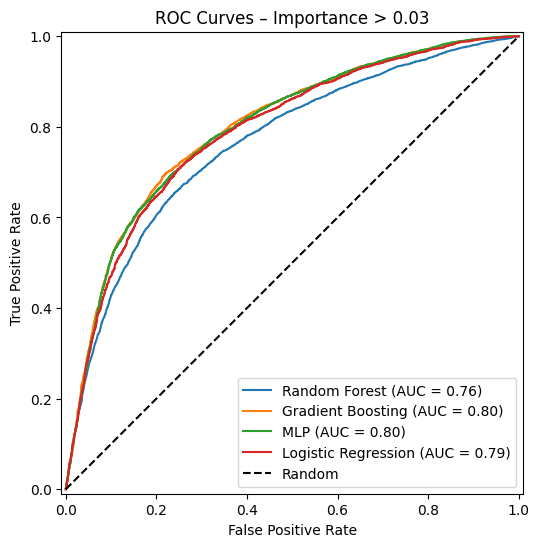

In [26]:
# For each dataset defined by feature importance thresholds (e.g., >0.01, >0.03),
# the data is split into train, validation, and test sets.
# Numeric features are scaled only for models that need it (MLP, Logistic Regression).
# Each model is trained on the training set and evaluated on the validation set.
# Metrics including accuracy, precision, recall, F1, F2, ROC-AUC are collected, and confusion matrices are plotted.
# ROC curves for all models are plotted together per dataset for easy comparison, with a diagonal representing a random classifier baseline.


all_results = []
roc_data = {}  # Store ROC info per dataset

# Loop through datasets defined by feature importance thresholds
for ds_name, X_data in datasets.items():
    print(f"\n=== Running models for {ds_name} ===")

    # Split dataset into train (70%) and temp (30%)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_data, y_full, test_size=0.3, random_state=42, stratify=y_full
    )
    # Further split temp into validation (15%) and test (15%)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )

    # Scale numeric features only for models that require it
    numeric_cols_ds = [col for col in numeric_cols if col in X_data.columns]
    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[numeric_cols_ds] = scaler.fit_transform(X_train[numeric_cols_ds])
    X_val_scaled[numeric_cols_ds] = scaler.transform(X_val[numeric_cols_ds])
    X_test_scaled[numeric_cols_ds] = scaler.transform(X_test[numeric_cols_ds])

    # Container to store ROC info for this dataset
    roc_data[ds_name] = []

    # Train and evaluate each model
    for name, info in models.items():
        print(f"Training {name}...")
        # Use scaled features if required
        X_tr = X_train_scaled if info["scaled"] else X_train
        X_vl = X_val_scaled if info["scaled"] else X_val

        # Fit model on training set
        info["model"].fit(X_tr, y_train)
        # Evaluate on validation set and get metrics + predicted probabilities
        metrics, y_proba = evaluate_model(
            info["model"], X_vl, y_val, model_name=f"{name} ({ds_name})", return_proba=True
        )
        all_results.append(metrics)

        # Collect ROC data for plotting
        if y_proba is not None:
            roc_data[ds_name].append((y_val, y_proba, name))

# Plot ROC curves for all models on the same graph per dataset
for ds_name, roc_list in roc_data.items():
    plt.figure(figsize=(8,6))
    for y_val, y_proba, name in roc_list:
        RocCurveDisplay.from_predictions(y_val, y_proba, name=name, ax=plt.gca())

    # Diagonal line for random classifier
    plt.plot([0,1], [0,1], 'k--', label='Random')
    plt.title(f'ROC Curves – {ds_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

Results Table

In [27]:
# Convert the collected metrics into a single DataFrame for easy comparison
results_df = pd.DataFrame(all_results)

# Display the evaluation results for all models across datasets
results_df

,Model,Accuracy,Precision,Recall,F1,F2,ROC-AUC
0,Random Forest (Importance > 0.01),0.714050,0.713237,0.705813,0.709505,0.707285,0.776206
1,Gradient Boosting (Importance > 0.01),0.738049,0.756531,0.693833,0.723827,0.705528,0.802985
2,MLP (Importance > 0.01),0.733288,0.743011,0.704635,0.723314,0.711990,0.798991
3,Logistic Regression (Importance > 0.01),0.726098,0.752051,0.665947,0.706385,0.681553,0.792249
4,Random Forest (Importance > 0.03),0.703750,0.701122,0.699332,0.700226,0.699690,0.763797
5,Gradient Boosting (Importance > 0.03),0.737369,0.751633,0.700707,0.725277,0.710332,0.800087
6,MLP (Importance > 0.03),0.730082,0.749784,0.682050,0.714315,0.694600,0.797670
7,Logistic Regression (Importance > 0.03),0.723863,0.750892,0.661233,0.703216,0.677410,0.790866


### Model Evaluation Summary

*   Gradient Boosting and MLP achieved the best overall performance, with Gradient Boosting having the highest ROC-AUC (≈0.80).
*   Random Forest showed solid accuracy but slightly lower ROC-AUC, while Logistic Regression had lower recall and F2, especially with fewer features.
*   Limiting features to importance >0.03 reduced model complexity
with minimal loss in predictive performance.

## <h2>Cross-Validation</h2>

In [28]:
def run_cv(models, datasets, y_full, numeric_cols, k=5):
    """
    Perform k-fold cross-validation for multiple models on multiple feature sets.

    Args:
        models (dict): Dictionary of models with their scaling info.
        datasets (dict): Dictionary of datasets keyed by feature selection threshold.
        y_full (pd.Series): Target variable.
        numeric_cols (list): List of numeric columns to scale if needed.
        k (int): Number of folds for Stratified K-Fold CV.

    Returns:
        pd.DataFrame: Aggregated mean ± std metrics for each model and dataset.
    """
    all_cv_results = []

    # Stratified K-Fold ensures class balance in each fold
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    for ds_name, X_data in datasets.items():
        print(f"\n===== Cross Validation for {ds_name} =====")

        for model_name, info in models.items():
            print(f"Running {model_name}...")

            # Store metrics per fold
            metrics_across_folds = {
                "accuracy": [], "precision": [], "recall": [],
                "f1": [], "f2": [], "roc_auc": []
            }

            # Loop over K folds
            for train_idx, val_idx in skf.split(X_data, y_full):
                X_train, X_val = X_data.iloc[train_idx], X_data.iloc[val_idx]
                y_train, y_val = y_full.iloc[train_idx], y_full.iloc[val_idx]

                # Scale numeric features if model requires it
                if info["scaled"]:
                    scaler = StandardScaler()
                    numeric_cols_ds = [col for col in numeric_cols if col in X_data.columns]
                    X_train_scaled = X_train.copy()
                    X_val_scaled = X_val.copy()
                    X_train_scaled[numeric_cols_ds] = scaler.fit_transform(X_train[numeric_cols_ds])
                    X_val_scaled[numeric_cols_ds] = scaler.transform(X_val[numeric_cols_ds])
                    X_tr, X_vl = X_train_scaled, X_val_scaled
                else:
                    X_tr, X_vl = X_train, X_val

                # Train the model
                model = info["model"]
                model.fit(X_tr, y_train)

                # Predictions and probabilities
                y_pred = model.predict(X_vl)
                y_proba = model.predict_proba(X_vl)[:,1] if hasattr(model, "predict_proba") else None

                # Collect metrics
                metrics_across_folds["accuracy"].append(accuracy_score(y_val, y_pred))
                metrics_across_folds["precision"].append(precision_score(y_val, y_pred))
                metrics_across_folds["recall"].append(recall_score(y_val, y_pred))
                metrics_across_folds["f1"].append(f1_score(y_val, y_pred))
                metrics_across_folds["f2"].append(fbeta_score(y_val, y_pred, beta=2))
                if y_proba is not None:
                    metrics_across_folds["roc_auc"].append(roc_auc_score(y_val, y_proba))

            # Aggregate metrics across folds (mean ± std)
            result = {
                "Dataset": ds_name,
                "Model": model_name,
                "Accuracy": f"{np.mean(metrics_across_folds['accuracy']):.4f} ± {np.std(metrics_across_folds['accuracy']):.4f}",
                "Precision": f"{np.mean(metrics_across_folds['precision']):.4f} ± {np.std(metrics_across_folds['precision']):.4f}",
                "Recall": f"{np.mean(metrics_across_folds['recall']):.4f} ± {np.std(metrics_across_folds['recall']):.4f}",
                "F1": f"{np.mean(metrics_across_folds['f1']):.4f} ± {np.std(metrics_across_folds['f1']):.4f}",
                "F2": f"{np.mean(metrics_across_folds['f2']):.4f} ± {np.std(metrics_across_folds['f2']):.4f}",
                "ROC-AUC": f"{np.mean(metrics_across_folds['roc_auc']):.4f} ± {np.std(metrics_across_folds['roc_auc']):.4f}"
            }

            all_cv_results.append(result)

    return pd.DataFrame(all_cv_results)

In [29]:
cv_results_df = run_cv(models, datasets, y_full, numeric_cols, k=5)
cv_results_df


===== Cross Validation for Importance > 0.01 =====
Running Random Forest...
Running Gradient Boosting...
Running MLP...
Running Logistic Regression...

===== Cross Validation for Importance > 0.03 =====
Running Random Forest...
Running Gradient Boosting...
Running MLP...
Running Logistic Regression...


,Dataset,Model,Accuracy,Precision,Recall,F1,F2,ROC-AUC
0,Importance > 0.01,Random Forest,0.7102 ± 0.0017,0.7118 ± 0.0019,0.6960 ± 0.0043,0.7038 ± 0.0023,0.6991 ± 0.0034,0.7705 ± 0.0019
1,Importance > 0.01,Gradient Boosting,0.7339 ± 0.0017,0.7516 ± 0.0027,0.6904 ± 0.0036,0.7197 ± 0.0019,0.7018 ± 0.0029,0.8008 ± 0.0029
2,Importance > 0.01,MLP,0.7321 ± 0.0018,0.7451 ± 0.0099,0.6975 ± 0.0135,0.7203 ± 0.0027,0.7064 ± 0.0093,0.7979 ± 0.0039
3,Importance > 0.01,Logistic Regression,0.7262 ± 0.0026,0.7526 ± 0.0033,0.6652 ± 0.0039,0.7062 ± 0.0030,0.6810 ± 0.0035,0.7907 ± 0.0038
4,Importance > 0.03,Random Forest,0.6981 ± 0.0017,0.6966 ± 0.0023,0.6903 ± 0.0054,0.6935 ± 0.0025,0.6916 ± 0.0042,0.7584 ± 0.0032
5,Importance > 0.03,Gradient Boosting,0.7324 ± 0.0019,0.7472 ± 0.0024,0.6941 ± 0.0046,0.7197 ± 0.0026,0.7041 ± 0.0038,0.7987 ± 0.0031
6,Importance > 0.03,MLP,0.7305 ± 0.0031,0.7445 ± 0.0055,0.6934 ± 0.0040,0.7180 ± 0.0026,0.7030 ± 0.0030,0.7957 ± 0.0046
7,Importance > 0.03,Logistic Regression,0.7250 ± 0.0035,0.7528 ± 0.0039,0.6614 ± 0.0046,0.7042 ± 0.0040,0.6779 ± 0.0043,0.7895 ± 0.0037


Key Insights from Cross-Validation
*   Gradient Boosting performed best overall, achieving the highest ROC-AUC (~0.80) and strong accuracy with very stable results across folds.
*   MLP achieved the highest F2 score, making it a strong candidate for medical use where recall (reducing false negatives) is important.
*   Using a feature importance threshold of > 0.01 gave slightly better results, while > 0.03 offered similar performance with fewer features.
*   Random Forest consistently underperformed and should not be considered further.
*   Logistic Regression performed reasonably but was mainly used as a baseline due to its simplicity.
*   All models showed low variance across folds, indicating stable and reliable performance.


## <h2>Hyperparameter Tuning</h2>

In [30]:
# Create a custom F2 scorer (emphasizes recall more than precision)
f2_scorer = make_scorer(fbeta_score, beta=2)

### <h3>Gradient Boosting Tuning</h3>

In [31]:
# Instantiate a Gradient Boosting classifier with a fixed random seed for reproducibility
gb_model = GradientBoostingClassifier(random_state=42)

# Define the hyperparameter grid to tune:
# - n_estimators: number of boosting rounds
# - learning_rate: step size for each boosting step
# - max_depth: maximum depth of each tree
gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

# Set up GridSearchCV to find the best hyperparameters
# - estimator: the model to tune
# - param_grid: hyperparameter combinations to try
# - scoring: use F2 score as the evaluation metric
# - cv: 5-fold cross-validation
# - n_jobs: 1 to avoid pickling issues (parallel processing disabled)
# - verbose: 1 to show progress
gb_grid = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_param_grid,
    scoring=f2_scorer,
    cv=5,
    n_jobs=1,
    verbose=1
)

# Select the dataset with feature importance > 0.01 for tuning
X_tune = datasets["Importance > 0.01"]

# Fit GridSearchCV to find the best hyperparameters
gb_grid.fit(X_tune, y_full)

# Print the best hyperparameters and corresponding F2 score
print("Best Gradient Boosting Params:", gb_grid.best_params_)
print("Best F2 Score:", gb_grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Gradient Boosting Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best F2 Score: 0.7032643143881944


Key Takeaways
*   Shallow trees (max_depth = 3) helped prevent overfitting
*   Moderate learning rate (0.1) provided stable learning
*   More estimators (200) improved overall performance
*   Optimising for F2 score prioritises recall, which is important for medical diagnosis

### <h3>MLP Tuning (WITH scaling)</h3>

In [32]:
# Create a pipeline for MLP with standard scaling
mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),            # Scale numeric features
    ("mlp", MLPClassifier(max_iter=300,      # Multi-layer Perceptron classifier
                          early_stopping=True,
                          random_state=42))
])

# Define hyperparameter grid for tuning
mlp_param_grid = {
    "mlp__hidden_layer_sizes": [(50,), (100,), (50,50)],  # Number of neurons/layers
    "mlp__alpha": [0.0001, 0.001],                        # L2 regularization
    "mlp__learning_rate_init": [0.001, 0.01]              # Initial learning rate
}

# Perform GridSearchCV to find best MLP hyperparameters using F2 score
mlp_grid = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=mlp_param_grid,
    scoring=f2_scorer,  # Use F2 to emphasize recall
    cv=5,
    n_jobs=1,
    verbose=1
)

# Fit on the selected dataset (Importance > 0.01 recommended)
mlp_grid.fit(X_tune, y_full)

# Display the best hyperparameters and corresponding F2 score
print("Best MLP Params:", mlp_grid.best_params_)
print("Best F2 Score:", mlp_grid.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best MLP Params: {'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (50,), 'mlp__learning_rate_init': 0.001}
Best F2 Score: 0.7132517852068474


Key Takeaways
*   A simple network (single hidden layer, 50 neurons) performed best
*   Low learning rate (0.001) enabled stable training
*   Regularisation (alpha = 0.001) helped reduce overfitting
*   Achieved a higher F2 score than Gradient Boosting, indicating better recall performance for this task.

## <h2>Evaluate final tuned models on the test set<h2>

Training MLP (0.01)...


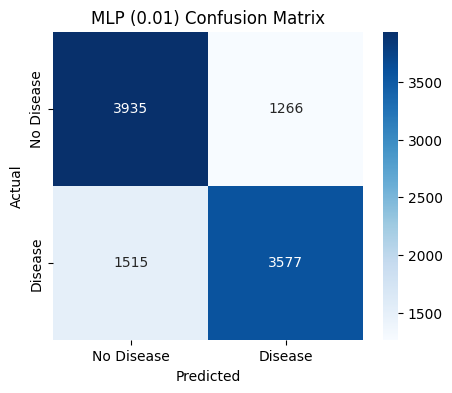

Training Gradient Boosting (0.01)...


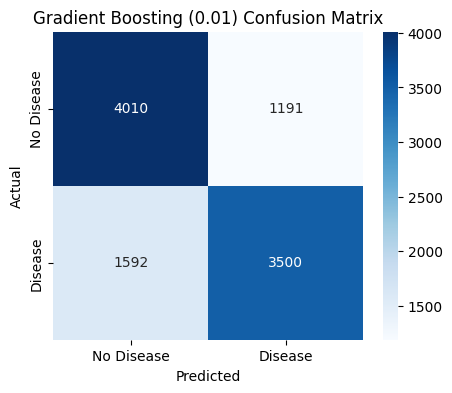

Training MLP (0.03)...


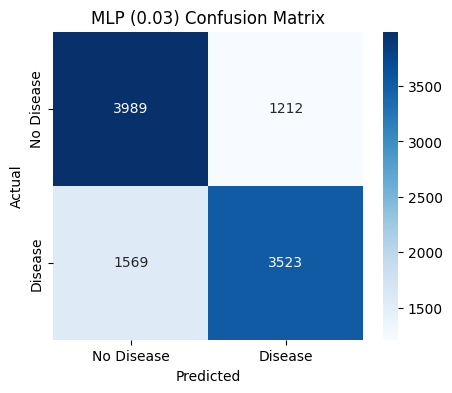

Training Gradient Boosting (0.03)...


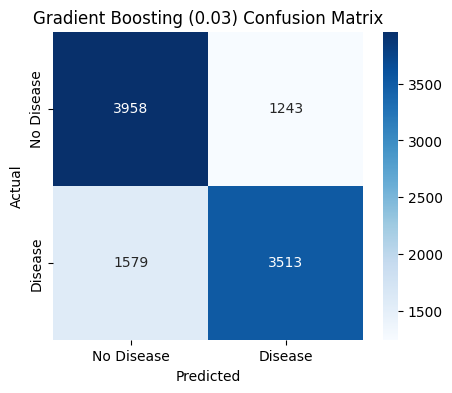

,Model,Accuracy,Precision,Recall,F1,F2,ROC-AUC
0,MLP (0.01),0.729816,0.738592,0.702474,0.720081,0.709413,0.793484
1,Gradient Boosting (0.01),0.729622,0.746110,0.687353,0.715527,0.698352,0.794475
2,MLP (0.03),0.729816,0.744034,0.691870,0.717004,0.701709,0.791080
3,Gradient Boosting (0.03),0.725833,0.738646,0.689906,0.713444,0.699132,0.792636


In [33]:
# Creates train/validation/test splits for features above importance thresholds 0.01 and 0.03
thresholds = [0.01, 0.03]
datasets = {}

for th in thresholds:
    # Selects features with importance above the threshold
    important_features = feature_importances[feature_importances > th].index.tolist()
    X_selected = X_full[important_features]

    # Splits into train (70%) and temp (30%) for further validation/test split
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_selected, y_full, test_size=0.3, random_state=42, stratify=y_full
    )
    # Splits temp into validation and test sets (each 15% of full data)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )

    # Stores all splits in a dictionary for each threshold
    datasets[f"{th}"] = {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test
    }

# Combines train + validation sets for final training
X_final_train_01 = pd.concat([datasets["0.01"]["X_train"], datasets["0.01"]["X_val"]])
y_final_train_01 = pd.concat([datasets["0.01"]["y_train"], datasets["0.01"]["y_val"]])

X_final_train_03 = pd.concat([datasets["0.03"]["X_train"], datasets["0.03"]["X_val"]])
y_final_train_03 = pd.concat([datasets["0.03"]["y_train"], datasets["0.03"]["y_val"]])

# Defines final models with tuned hyperparameters
final_models = {
    "MLP (0.01)": {
        "model": MLPClassifier(hidden_layer_sizes=(50,), alpha=0.001, learning_rate_init=0.001,
                               max_iter=500, early_stopping=True, random_state=42),
        "scaled": True, "X_train": X_final_train_01, "y_train": y_final_train_01,
        "X_test": datasets["0.01"]["X_test"], "y_test": datasets["0.01"]["y_test"]
    },
    "Gradient Boosting (0.01)": {
        "model": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                            max_depth=3, random_state=42),
        "scaled": False, "X_train": X_final_train_01, "y_train": y_final_train_01,
        "X_test": datasets["0.01"]["X_test"], "y_test": datasets["0.01"]["y_test"]
    },
    "MLP (0.03)": {
        "model": MLPClassifier(hidden_layer_sizes=(50,), alpha=0.001, learning_rate_init=0.001,
                               max_iter=500, early_stopping=True, random_state=42),
        "scaled": True, "X_train": X_final_train_03, "y_train": y_final_train_03,
        "X_test": datasets["0.03"]["X_test"], "y_test": datasets["0.03"]["y_test"]
    },
    "Gradient Boosting (0.03)": {
        "model": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                            max_depth=3, random_state=42),
        "scaled": False, "X_train": X_final_train_03, "y_train": y_final_train_03,
        "X_test": datasets["0.03"]["X_test"], "y_test": datasets["0.03"]["y_test"]
    },
}

# Scales numeric features for models that require it
numeric_cols_ds = ['age', 'height', 'weight', 'bmi', 'ap_hi', 'ap_lo']
for name, info in final_models.items():
    if info["scaled"]:
        scaler = StandardScaler()
        X_tr_scaled = info["X_train"].copy()
        X_te_scaled = info["X_test"].copy()
        cols = [col for col in numeric_cols_ds if col in info["X_train"].columns]
        X_tr_scaled[cols] = scaler.fit_transform(info["X_train"][cols])
        X_te_scaled[cols] = scaler.transform(info["X_test"][cols])
        info["X_train_scaled"] = X_tr_scaled
        info["X_test_scaled"] = X_te_scaled
    else:
        # Use original features if no scaling is needed
        info["X_train_scaled"] = info["X_train"]
        info["X_test_scaled"] = info["X_test"]

# Defines evaluation function for final models
def evaluate_final_model(model, X_test, y_test, model_name="Model"):
    # Predict labels and probabilities
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    # Computes metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    f2 = fbeta_score(y_test, y_pred, beta=2)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    # Plots confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease','Disease'], yticklabels=['No Disease','Disease'])
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {"Model": model_name, "Accuracy": acc, "Precision": prec,
            "Recall": rec, "F1": f1, "F2": f2, "ROC-AUC": roc_auc, "y_proba": y_proba, "y_test": y_test}

# Trains and evaluates all final models
final_results = []
for name, info in final_models.items():
    print(f"Training {name}...")
    X_tr = info["X_train_scaled"]
    X_te = info["X_test_scaled"]
    model = info["model"]
    model.fit(X_tr, info["y_train"])
    metrics = evaluate_final_model(model, X_te, info["y_test"], model_name=name)
    final_results.append(metrics)

# Creates a summary table of evaluation metrics (excluding raw predictions)
summary_df = pd.DataFrame([{k:v for k,v in m.items() if k not in ['y_proba','y_test']}
                           for m in final_results])
summary_df

All models show similar performance (Accuracy ~0.73, ROC-AUC ~0.79), with most predictive power captured by the top features. MLP slightly favors precision, while Gradient Boosting slightly favors recall, suggesting model choice can be guided by whether minimizing false positives or maximizing disease detection is more important.


## <h2> Visualize ROC Curves for Final Models (0.01 vs 0.03 thresholds) <h2>




f:\AllMyCode\Cardiovascular_Disease\cardio\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
f:\AllMyCode\Cardiovascular_Disease\cardio\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


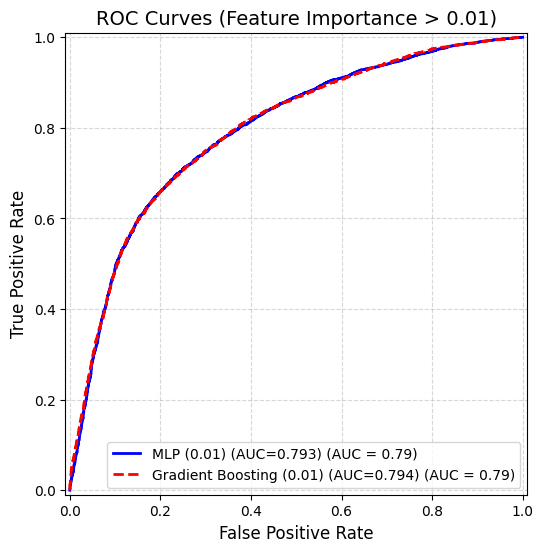

f:\AllMyCode\Cardiovascular_Disease\cardio\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
f:\AllMyCode\Cardiovascular_Disease\cardio\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


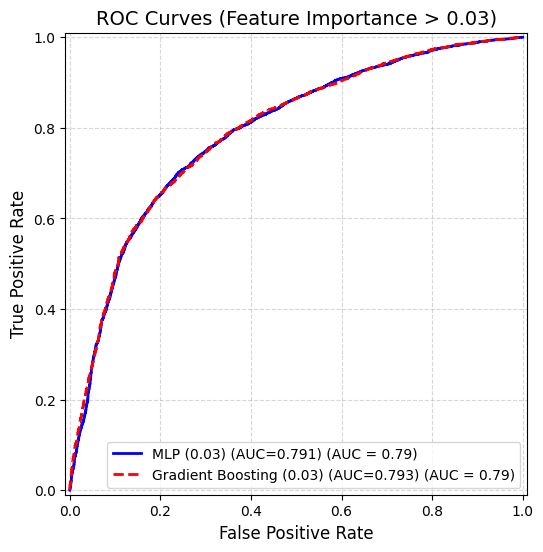

In [34]:
# Map base model types to colors and line styles for consistent ROC visualization
colors = {
    "MLP": "blue",
    "Gradient Boosting": "red"
}
linestyles = {
    "MLP": "-",
    "Gradient Boosting": "--"
}

# Group the final models by feature importance threshold for plotting
roc_datasets = {
    "0.01": ["MLP (0.01)", "Gradient Boosting (0.01)"],
    "0.03": ["MLP (0.03)", "Gradient Boosting (0.03)"]
}

# Loop over each feature importance threshold
for thresh, model_names in roc_datasets.items():
    plt.figure(figsize=(8,6))
    ax = plt.gca()  # Use the same axes to overlay both models' ROC curves

    # Plot ROC curve for each model at this threshold
    for model_name in model_names:
        # Retrieve test labels, predicted probabilities, and AUC for the model
        metrics = next(m for m in final_results if m["Model"] == model_name)
        y_test = metrics["y_test"]
        y_proba = metrics["y_proba"]
        auc = metrics["ROC-AUC"]

        # Determine the base model type (MLP or Gradient Boosting) for color/style mapping
        base_model = "MLP" if "MLP" in model_name else "Gradient Boosting"

        # Plot ROC curve with proper labeling, color, and line style
        RocCurveDisplay.from_predictions(
            y_test,
            y_proba,
            name=f"{model_name} (AUC={auc:.3f})",
            color=colors[base_model],
            linestyle=linestyles[base_model],
            linewidth=2,
            ax=ax
        )

    # Set titles, labels, legend, and grid for clarity
    plt.title(f"ROC Curves (Feature Importance > {thresh})", fontsize=14)
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.5)

    # Display the ROC plot
    plt.show()

## <h2>Use permutation importance to approximate feature influence for MLP</h2>

Computing permutation importance: MLP (0.01)...
Computing permutation importance: Gradient Boosting (0.01)...
Computing permutation importance: MLP (0.03)...
Computing permutation importance: Gradient Boosting (0.03)...


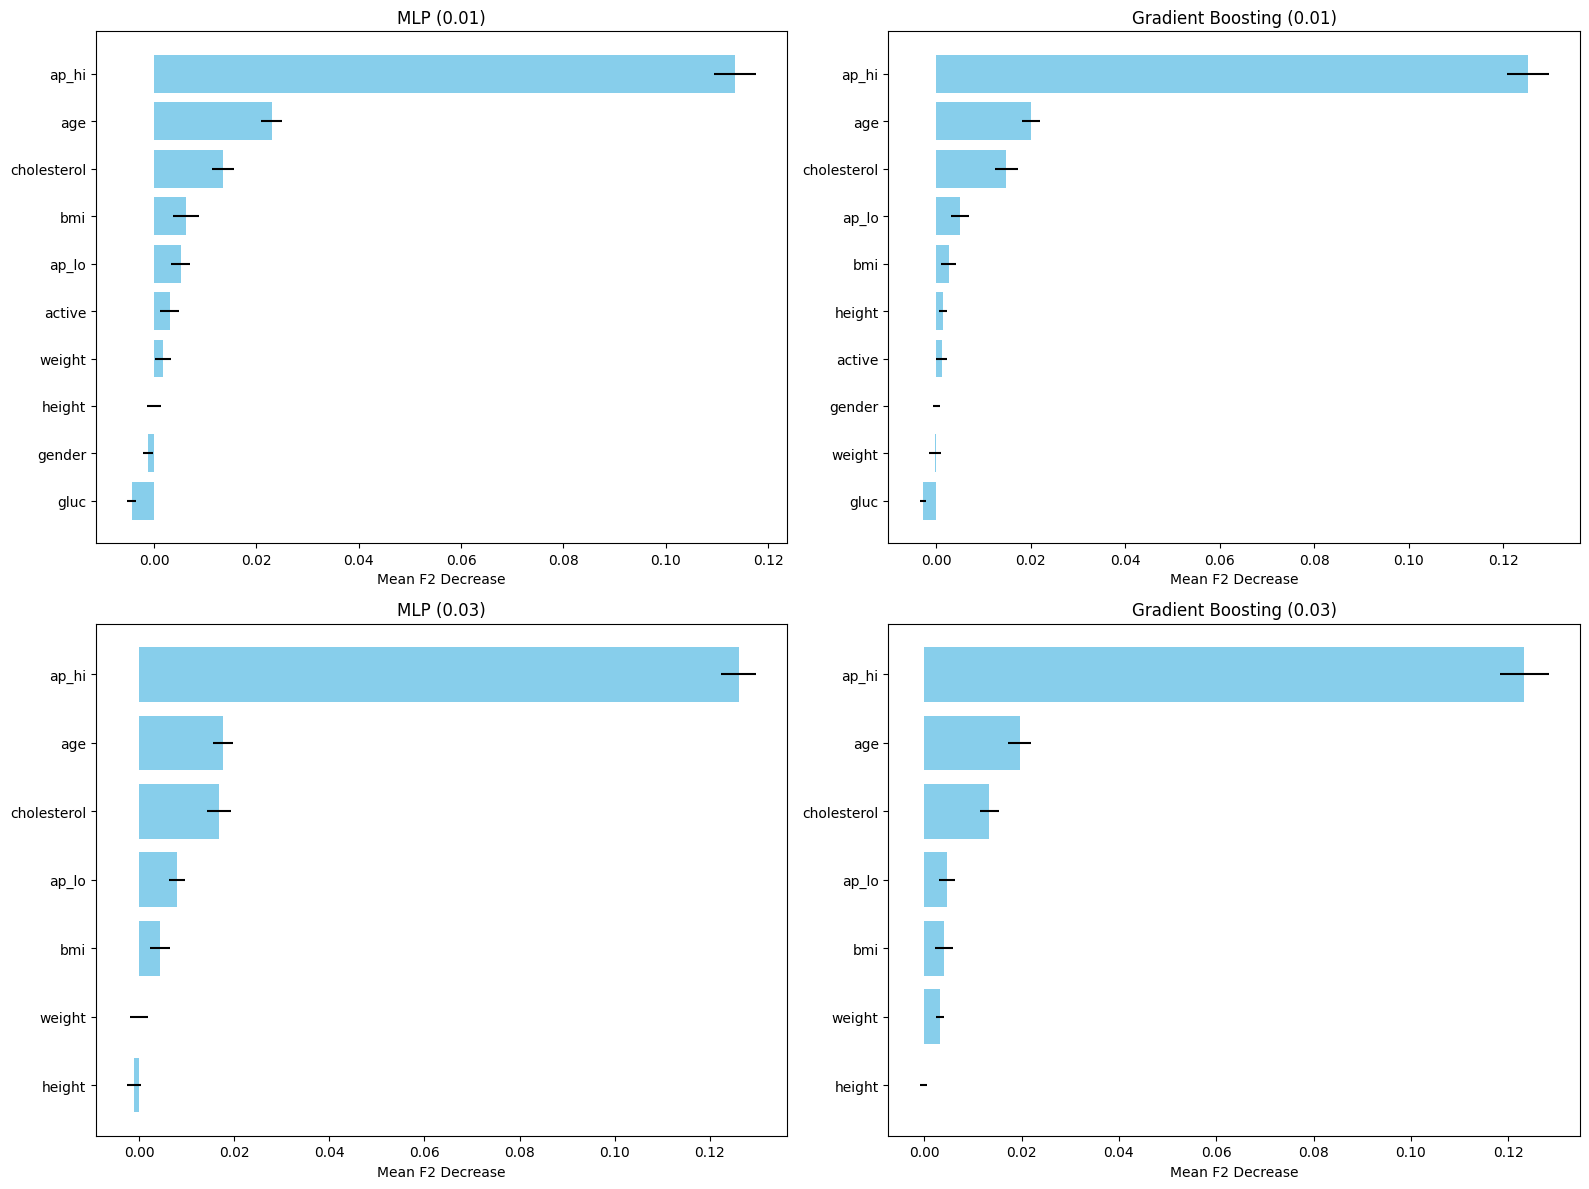

In [35]:
# Create an F2 scorer to use in permutation importance (gives more weight to recall)
f2_scorer = make_scorer(fbeta_score, beta=2)

# Define the order of models in the 2x2 plot grid
grid_order = [
    "MLP (0.01)", "Gradient Boosting (0.01)",
    "MLP (0.03)", "Gradient Boosting (0.03)"
]

# Create a 2x2 subplot grid for visualizing permutation importance
fig, axes = plt.subplots(2, 2, figsize=(16,12))
axes = axes.flatten()  # Flatten to easily index subplots

# Loop over models in the defined order
for idx, model_name in enumerate(grid_order):
    info = final_models[model_name]       # Get model info (data and model object)
    X_te = info["X_test_scaled"]          # Test features (scaled if needed)
    y_te = info["y_test"]                 # True labels
    model = info["model"]                 # Trained model

    print(f"Computing permutation importance: {model_name}...")

    # Compute permutation importance using F2 score
    perm_result = permutation_importance(
        model, X_te, y_te,
        n_repeats=30,          # Repeat permutations 30 times for stability
        random_state=42,
        scoring=f2_scorer
    )

    # Sort features by mean importance (descending)
    sorted_idx = perm_result.importances_mean.argsort()[::-1]

    # Plot horizontal bar chart in assigned subplot
    ax = axes[idx]
    ax.barh(
        X_te.columns[sorted_idx],                  # Feature names sorted
        perm_result.importances_mean[sorted_idx], # Mean importance
        xerr=perm_result.importances_std[sorted_idx], # Show std deviation
        color='skyblue'
    )
    ax.invert_yaxis()        # Highest importance at top
    ax.set_xlabel("Mean F2 Decrease")  # Label for x-axis
    ax.set_title(model_name)          # Title for each subplot

# Adjust spacing to avoid overlap
plt.tight_layout()
plt.show()